<a href="https://colab.research.google.com/github/ababilkhoerulimam/text-processing-week4/blob/main/ababil%20bethania_exercise%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 3 - Web Scraping (HTTP Request & API)

**Chapter 3 - Web Scraping**

Target website: https://news.ycombinator.com/

Anggota Kelompok (2 mahasiswa):
1. Ababil Khoerul Imam - 152
2. Bethania Putri Junjungsari Nugraha - 115

**Tugas:** Melakukan scraping terhadap sebuah website menggunakan dua pendekatan, yaitu:
1. **HTTP Request** langsung ke halaman web (`requests` + `BeautifulSoup`)
2. **API** (Application Programming Interface) yang menyediakan data terkait website tersebut

## 0. Persiapan (Import Library)

Library yang digunakan mengikuti materi Chapter 3:
- `requests` untuk mengambil dokumen HTML/JSON dari internet
- `BeautifulSoup` untuk mem-parsing (membaca struktur) dokumen HTML
- `pandas` untuk menyimpan hasil scraping ke dalam bentuk tabel (DataFrame)
- `matplotlib.pyplot` untuk memvisualisasikan data hasil scraping

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt

## 1. Web Scraping dengan HTTP Request

Pada bagian ini kita melakukan request langsung ke halaman utama Hacker News (`https://news.ycombinator.com/`) menggunakan library `requests`, kemudian mem-parsing struktur HTML menggunakan `BeautifulSoup` untuk mengekstrak daftar thread artikel, tautan URL, skor poin, dan pembuat postingan.

In [2]:
# Fetch raw HTML from Hacker News frontpage
url = 'https://news.ycombinator.com/'

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/124.0 Safari/537.36'
}

page = requests.get(url, headers=headers)
page

<Response [200]>

In [3]:
print(page.text[:1500])

<html lang="en" op="news"><head><meta name="referrer" content="origin"><meta name="viewport" content="width=device-width, initial-scale=1.0"><link rel="icon" href="y18.svg"><link rel="stylesheet" type="text/css" href="news.css?p9DVimPa4KE9hyScgN6l"><link rel="alternate" type="application/rss+xml" title="RSS" href="rss"><title>Hacker News</title></head><body><center><table id="hnmain" border="0" cellpadding="0" cellspacing="0" width="85%" bgcolor="#f6f6ef"><tr><td bgcolor="#ff6600"><table border="0" cellpadding="0" cellspacing="0" width="100%" style="padding:2px"><tr><td style="width:18px;padding-right:4px"><a href="https://news.ycombinator.com"><img src="y18.svg" width="18" height="18" style="border:1px white solid; display:block"></a></td><td style="line-height:12pt; height:10px;"><span class="pagetop"><b class="hnname"><a href="news">Hacker News</a></b><a href="newest">new</a> | <a href="front">past</a> | <a href="newcomments">comments</a> | <a href="ask">ask</a> | <a href="show">sho

In [4]:
# Parse HTML markup using BeautifulSoup
bs = BeautifulSoup(page.text, 'html.parser')
bs.title

<title>Hacker News</title>

In [5]:
judul = bs.find('title').text
total_baris_artikel = len(bs.find_all('tr', class_='athing'))

print('Judul Halaman:', judul)
print('Total Baris Artikel (athing):', total_baris_artikel)

Judul Halaman: Hacker News
Total Baris Artikel (athing): 30


In [6]:
# Extract story IDs, titles, and target URLs from table rows
rows = bs.find_all('tr', class_='athing')

daftar_artikel = []
for r in rows:
    story_id = r.get('id')
    title_span = r.find('span', class_='titleline')
    title_a = title_span.find('a') if title_span else None
    if title_a:
        daftar_artikel.append({
            'id': story_id,
            'title': title_a.text.strip(),
            'url': title_a.get('href')
        })

df_http = pd.DataFrame(daftar_artikel)
print('Jumlah artikel ditemukan:', len(df_http))
df_http.head(10)

Jumlah artikel ditemukan:

 30


,id,title,url
0,49906637,Pi.dev: You Said No MCP,https://earendil.com/posts/you-said-no-mcp/
1,49908962,SDF vs. MSDF vs. Slug: GPU Text Rendering,https://alphapixeldev.com/sdf-vs-msdf-vs-slug-...
2,49890707,Show HN: JBR-001 – An open-source 3D printable...,https://projecthub.arduino.cc/syntheticaidata/...
3,49901736,Livenerf: Has Opus 5.5 been nerfed yet?,https://github.com/ninjahawk/livenerf
4,49889140,Mathematical Origami,https://mathigon.org/origami
5,49887343,Solving Factorio Quality,https://exyr.org/2026/solving-factorio-quality/
6,49883970,I Could've Accessed 17T Microsoft Records,https://blog.faav.net/how-i-couldve-accessed-1...
7,49879346,Getting out of the way: my robotics crash course,https://thisismypersonalblog.com/posts/2026-09...
8,49896604,Dots: Always-on agents,https://openai.com/index/introducing-dots/
9,49897993,Vermont replacing power plants with home batte...,https://www.bbc.com/future/article/20260928-a-...


In [7]:
# Extract story upvote scores and authors from subtext metadata
subtext_rows = bs.find_all('td', class_='subtext')

poin_list = []
author_list = []
for sub in subtext_rows:
    score_elem = sub.find('span', class_='score')
    author_elem = sub.find('a', class_='hnuser')
    poin = score_elem.text.replace(' points', '').replace(' point', '').strip() if score_elem else '0'
    author = author_elem.text.strip() if author_elem else 'anonymous'
    poin_list.append(int(poin) if poin.isdigit() else 0)
    author_list.append(author)

if len(poin_list) == len(df_http):
    df_http['score'] = poin_list
    df_http['author'] = author_list

df_http[['id', 'title', 'score', 'author']].head(10)

,id,title,score,author
0,49906637,Pi.dev: You Said No MCP,377,yarapavan
1,49908962,SDF vs. MSDF vs. Slug: GPU Text Rendering,38,ibobev
2,49890707,Show HN: JBR-001 – An open-source 3D printable...,87,gvuksic
3,49901736,Livenerf: Has Opus 5.5 been nerfed yet?,784,bryan0
4,49889140,Mathematical Origami,53,signa11
5,49887343,Solving Factorio Quality,187,laurenth
6,49883970,I Could've Accessed 17T Microsoft Records,19,luispa
7,49879346,Getting out of the way: my robotics crash course,12,systemerror
8,49896604,Dots: Always-on agents,700,alvis
9,49897993,Vermont replacing power plants with home batte...,303,devonnull


**Catatan karakteristik website:**

`news.ycombinator.com` menggunakan arsitektur server-side rendering murni dengan markup HTML berbasis tabel (`<table>`, `<tr>`, `<td>`). Struktur statis ini memungkinkan library `requests` dan `BeautifulSoup` mengekstrak seluruh konten utama secara lengkap tanpa memerlukan browser automation engine (seperti Selenium atau Playwright).

## 2. Web Scraping dengan API

Hacker News menyediakan Official REST API gratis yang di-host di Google Firebase (`https://hacker-news.firebaseio.com/v0/`). API ini bersifat open access (tanpa perlu API key) dan mengembalikan data dalam format JSON terstruktur untuk berbagai entitas, termasuk `topstories`, `newstories`, dan detail `item` berdasarkan ID.

Dokumentasi resmi: https://github.com/HackerNews/API

In [8]:
# Retrieve top story IDs from Firebase REST API
url_top = 'https://hacker-news.firebaseio.com/v0/topstories.json'
response_top = requests.get(url_top)

print('Status code:', response_top.status_code)
if response_top.status_code == 200:
    top_ids = response_top.json()
    print('Jumlah ID top stories tersedia:', len(top_ids))
    print('Contoh 10 ID pertama:', top_ids[:10])

Status code: 200
Jumlah ID top stories tersedia: 500
Contoh 10 ID pertama: [49906637, 49908962, 49890707, 49901736, 49889140, 49883970, 49887343, 49879346, 49896604, 49897993]


In [9]:
# Fetch detailed payload for one sample story
sample_id = top_ids[0]
url_item = f'https://hacker-news.firebaseio.com/v0/item/{sample_id}.json'
sample_item = requests.get(url_item).json()

print('ID         :', sample_item.get('id'))
print('Judul      :', sample_item.get('title'))
print('Author     :', sample_item.get('by'))
print('Skor (Up)  :', sample_item.get('score'))
print('Komentar   :', sample_item.get('descendants'))
print('URL        :', sample_item.get('url'))

ID         : 49906637
Judul      : Pi.dev: You Said No MCP
Author     : yarapavan
Skor (Up)  : 377
Komentar   : 199
URL        : https://earendil.com/posts/you-said-no-mcp/


In [10]:
# Fetch detailed metadata for the top 30 stories
stories_data = []

for sid in top_ids[:30]:
    item_url = f'https://hacker-news.firebaseio.com/v0/item/{sid}.json'
    res = requests.get(item_url)
    if res.status_code == 200:
        data = res.json()
        if data:
            stories_data.append({
                'id': data.get('id'),
                'title': data.get('title'),
                'by': data.get('by'),
                'score': data.get('score', 0),
                'comments': data.get('descendants', 0),
                'time': data.get('time'),
                'url': data.get('url')
            })

print('Total stories berhasil diunduh via API:', len(stories_data))

Total stories berhasil diunduh via API: 30


In [11]:
# Structure payload into DataFrame and convert UNIX timestamps to UTC
df_api = pd.DataFrame(stories_data)
df_api['datetime_utc'] = pd.to_datetime(df_api['time'], unit='s')

print('Dimensi data:', df_api.shape)
df_api[['id', 'title', 'by', 'score', 'comments', 'datetime_utc']].head(10)

Dimensi data: (30, 8)


,id,title,by,score,comments,datetime_utc
0,49906637,Pi.dev: You Said No MCP,yarapavan,377,199,2026-09-30 09:55:23
1,49908962,SDF vs. MSDF vs. Slug: GPU Text Rendering,ibobev,39,21,2026-09-30 13:50:50
2,49890707,Show HN: JBR-001 – An open-source 3D printable...,gvuksic,88,15,2026-09-29 10:05:56
3,49901736,Livenerf: Has Opus 5.5 been nerfed yet?,bryan0,785,331,2026-09-29 22:36:14
4,49889140,Mathematical Origami,signa11,54,12,2026-09-29 06:45:46
5,49883970,I Could've Accessed 17T Microsoft Records,luispa,20,4,2026-09-28 20:32:46
6,49887343,Solving Factorio Quality,laurenth,188,63,2026-09-29 02:27:54
7,49879346,Getting out of the way: my robotics crash course,systemerror,14,2,2026-09-28 15:12:43
8,49896604,Dots: Always-on agents,alvis,700,571,2026-09-29 17:07:57
9,49897993,Vermont replacing power plants with home batte...,devonnull,303,230,2026-09-29 18:19:02


In [12]:
# Export scraped API data to CSV
csv_filename = 'hackernews_stories.csv'
df_api.to_csv(csv_filename, index=False)
print(f'File berhasil disimpan: {csv_filename} dengan dimensi {df_api.shape}')

File berhasil disimpan: hackernews_stories.csv dengan dimensi (30, 8)


### 2.6 Analisis Singkat & Visualisasi Data Scraping API

Sebagai pemanfaatan data hasil scraping API, kita melakukan eksplorasi sederhana:
1. Top 10 stories dengan skor upvotes tertinggi
2. Distribusi statistik skor dan jumlah komentar
3. Frekuensi kontributor (penulis postingan) teraktif

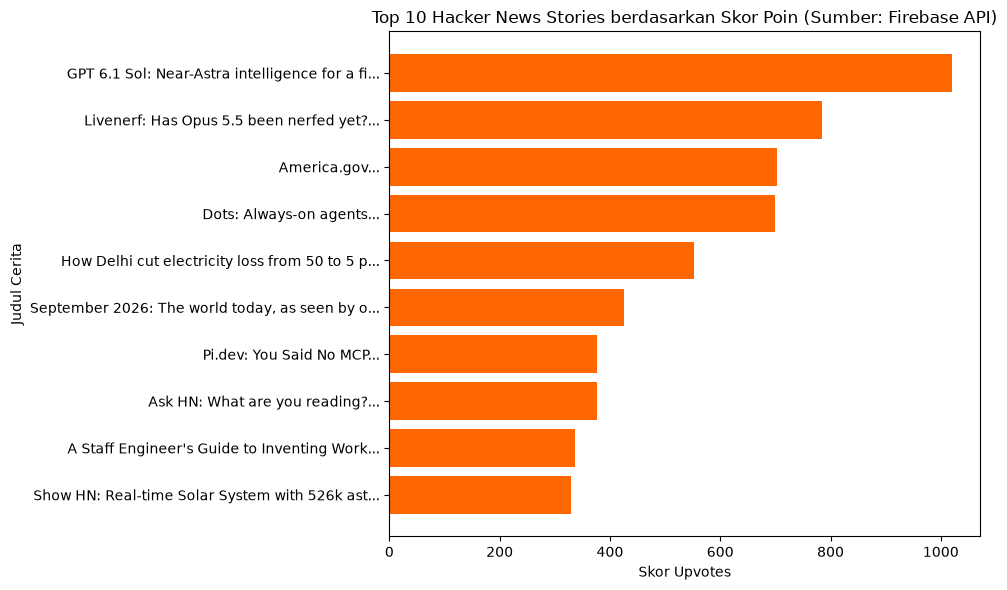

In [13]:
# Visualize top 10 stories by upvote score
top10_stories = df_api.sort_values(by='score', ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_stories['title'].str[:45] + '...', top10_stories['score'], color='#ff6600')
plt.title('Top 10 Hacker News Stories berdasarkan Skor Poin (Sumber: Firebase API)')
plt.xlabel('Skor Upvotes')
plt.ylabel('Judul Cerita')
plt.tight_layout()
plt.show()

In [14]:
df_api[['score', 'comments']].describe()

,score,comments
count,30.000000,30.000000
mean,273.866667,177.166667
std,256.864480,235.721648
min,14.000000,2.000000
25%,74.500000,15.750000
50%,220.500000,66.000000
75%,366.000000,265.250000
max,1020.000000,891.000000


In [15]:
df_api['by'].value_counts().head(10)

by
ilamont        2
yarapavan      1
ibobev         1
gvuksic        1
bryan0         1
signa11        1
luispa         1
laurenth       1
systemerror    1
alvis          1
Name: count, dtype: int64

## 3. Kesimpulan

* **HTTP Request** menggunakan `requests` dan `BeautifulSoup` berhasil mengekstrak 30 artikel pada halaman utama `news.ycombinator.com`. Karena website ini menggunakan server-side rendering berbasis tabel HTML standar (`.athing` dan `.subtext`), seluruh judul artikel, tautan, dan poin dapat diparsing secara lengkap tanpa kehilangan data elemen.

* **API** menggunakan official Firebase REST API (`hacker-news.firebaseio.com`) memberikan pendekatan yang jauh lebih stabil, presisi, dan terstruktur. Nilai numerik seperti ID story, skor upvotes aktual, total komentar (`descendants`), dan timestamp UNIX dapat diakses langsung dalam format JSON tanpa risiko kerapuhan selector CSS HTML.

* Dataset yang dihasilkan, `hackernews_stories.csv`, berisi 30 baris data riil dengan kolom `title` yang kaya akan teks natural berbahasa Inggris. Dataset ini siap dan valid untuk digunakan pada tahap berikutnya, yaitu **Exercise 4 (Text Pre-processing)**, untuk proses case folding, tokenizing, stopword removal, dan stemming.

# Exercise 4

## Text Pre-processing

Try to preprocess the text you scrape from the Exercise 3.

Pada exercise ini, text yang digunakan adalah **title** dari data Hacker News yang sudah diperoleh pada Exercise 3 (`df_api`).

### 1. Menampilkan Text Hasil Scraping dari Exercise 3

In [16]:
df_api[['id', 'title']].head(10)

,id,title
0,49906637,Pi.dev: You Said No MCP
1,49908962,SDF vs. MSDF vs. Slug: GPU Text Rendering
2,49890707,Show HN: JBR-001 – An open-source 3D printable...
3,49901736,Livenerf: Has Opus 5.5 been nerfed yet?
4,49889140,Mathematical Origami
5,49883970,I Could've Accessed 17T Microsoft Records
6,49887343,Solving Factorio Quality
7,49879346,Getting out of the way: my robotics crash course
8,49896604,Dots: Always-on agents
9,49897993,Vermont replacing power plants with home batte...


### 2. Remove HTML

In [17]:
import re

# Strip HTML tags
def remove_html(text):
    html_pattern = re.compile('<.*?>')
    return html_pattern.sub(r'', text)

df_api['rm_html'] = df_api['title'].apply(remove_html)
df_api[['title', 'rm_html']].head(10)

,title,rm_html
0,Pi.dev: You Said No MCP,Pi.dev: You Said No MCP
1,SDF vs. MSDF vs. Slug: GPU Text Rendering,SDF vs. MSDF vs. Slug: GPU Text Rendering
2,Show HN: JBR-001 – An open-source 3D printable...,Show HN: JBR-001 – An open-source 3D printable...
3,Livenerf: Has Opus 5.5 been nerfed yet?,Livenerf: Has Opus 5.5 been nerfed yet?
4,Mathematical Origami,Mathematical Origami
5,I Could've Accessed 17T Microsoft Records,I Could've Accessed 17T Microsoft Records
6,Solving Factorio Quality,Solving Factorio Quality
7,Getting out of the way: my robotics crash course,Getting out of the way: my robotics crash course
8,Dots: Always-on agents,Dots: Always-on agents
9,Vermont replacing power plants with home batte...,Vermont replacing power plants with home batte...


### 3. Remove Hashtag

In [18]:
# Remove hashtag tokens
def remove_hashtag(text):
    return re.sub(r'#\w+', '', text)

df_api['rm_hashtag'] = df_api['rm_html'].apply(remove_hashtag)
df_api[['rm_html', 'rm_hashtag']].head(10)

,rm_html,rm_hashtag
0,Pi.dev: You Said No MCP,Pi.dev: You Said No MCP
1,SDF vs. MSDF vs. Slug: GPU Text Rendering,SDF vs. MSDF vs. Slug: GPU Text Rendering
2,Show HN: JBR-001 – An open-source 3D printable...,Show HN: JBR-001 – An open-source 3D printable...
3,Livenerf: Has Opus 5.5 been nerfed yet?,Livenerf: Has Opus 5.5 been nerfed yet?
4,Mathematical Origami,Mathematical Origami
5,I Could've Accessed 17T Microsoft Records,I Could've Accessed 17T Microsoft Records
6,Solving Factorio Quality,Solving Factorio Quality
7,Getting out of the way: my robotics crash course,Getting out of the way: my robotics crash course
8,Dots: Always-on agents,Dots: Always-on agents
9,Vermont replacing power plants with home batte...,Vermont replacing power plants with home batte...


### 4. Lower Casing

In [19]:
# Case folding to lowercase
df_api['lower_case'] = df_api['rm_hashtag'].str.lower()
df_api[['rm_hashtag', 'lower_case']].head(10)

,rm_hashtag,lower_case
0,Pi.dev: You Said No MCP,pi.dev: you said no mcp
1,SDF vs. MSDF vs. Slug: GPU Text Rendering,sdf vs. msdf vs. slug: gpu text rendering
2,Show HN: JBR-001 – An open-source 3D printable...,show hn: jbr-001 – an open-source 3d printable...
3,Livenerf: Has Opus 5.5 been nerfed yet?,livenerf: has opus 5.5 been nerfed yet?
4,Mathematical Origami,mathematical origami
5,I Could've Accessed 17T Microsoft Records,i could've accessed 17t microsoft records
6,Solving Factorio Quality,solving factorio quality
7,Getting out of the way: my robotics crash course,getting out of the way: my robotics crash course
8,Dots: Always-on agents,dots: always-on agents
9,Vermont replacing power plants with home batte...,vermont replacing power plants with home batte...


### 5. Remove URL and Email

In [20]:
# Strip URLs and email addresses
def remove_rls(text):
    text = re.sub(r'https?://\S+|www\.\S+', '', str(text))
    text = re.sub(r'\S+@\S+', '', str(text))
    return text

df_api['rm_url'] = df_api['lower_case'].apply(remove_rls)
df_api[['lower_case', 'rm_url']].head(10)

,lower_case,rm_url
0,pi.dev: you said no mcp,pi.dev: you said no mcp
1,sdf vs. msdf vs. slug: gpu text rendering,sdf vs. msdf vs. slug: gpu text rendering
2,show hn: jbr-001 – an open-source 3d printable...,show hn: jbr-001 – an open-source 3d printable...
3,livenerf: has opus 5.5 been nerfed yet?,livenerf: has opus 5.5 been nerfed yet?
4,mathematical origami,mathematical origami
5,i could've accessed 17t microsoft records,i could've accessed 17t microsoft records
6,solving factorio quality,solving factorio quality
7,getting out of the way: my robotics crash course,getting out of the way: my robotics crash course
8,dots: always-on agents,dots: always-on agents
9,vermont replacing power plants with home batte...,vermont replacing power plants with home batte...


### 6. Remove Punctuation

In [21]:
import string

# Strip emoticons and ASCII/Unicode punctuation
def remove_punctuation_list(text):
    text = re.sub(r'(:\)|:-\)|:D|:-D|;\)|;-\))', '', text)
    text = re.sub(r'(:\(|:-\()', '', text)
    text = re.sub(r'(:v|:-v)', '', text)

    punc = re.escape(string.punctuation) + '–—‘’“”«»…'
    text = re.sub(f'[{punc}]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_api['rm_punc'] = df_api['rm_url'].apply(remove_punctuation_list)
df_api[['rm_url', 'rm_punc']].head(10)

,rm_url,rm_punc
0,pi.dev: you said no mcp,pi dev you said no mcp
1,sdf vs. msdf vs. slug: gpu text rendering,sdf vs msdf vs slug gpu text rendering
2,show hn: jbr-001 – an open-source 3d printable...,show hn jbr 001 an open source 3d printable de...
3,livenerf: has opus 5.5 been nerfed yet?,livenerf has opus 5 5 been nerfed yet
4,mathematical origami,mathematical origami
5,i could've accessed 17t microsoft records,i could ve accessed 17t microsoft records
6,solving factorio quality,solving factorio quality
7,getting out of the way: my robotics crash course,getting out of the way my robotics crash course
8,dots: always-on agents,dots always on agents
9,vermont replacing power plants with home batte...,vermont replacing power plants with home batte...


### 7. Remove Emoji

In [22]:
!pip install demoji

import demoji

# Remove emojis using demoji library
def remove_emoji(text):
    return demoji.replace(text, repl="")

df_api['rm_emoji'] = df_api['rm_punc'].apply(remove_emoji)
df_api[['rm_punc', 'rm_emoji']].head(10)

,rm_punc,rm_emoji
0,pi dev you said no mcp,pi dev you said no mcp
1,sdf vs msdf vs slug gpu text rendering,sdf vs msdf vs slug gpu text rendering
2,show hn jbr 001 an open source 3d printable de...,show hn jbr 001 an open source 3d printable de...
3,livenerf has opus 5 5 been nerfed yet,livenerf has opus 5 5 been nerfed yet
4,mathematical origami,mathematical origami
5,i could ve accessed 17t microsoft records,i could ve accessed 17t microsoft records
6,solving factorio quality,solving factorio quality
7,getting out of the way my robotics crash course,getting out of the way my robotics crash course
8,dots always on agents,dots always on agents
9,vermont replacing power plants with home batte...,vermont replacing power plants with home batte...


### 8. Tokenizing

In [23]:
import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Tokenize string into word tokens
def tokenize_text(text):
    return nltk.word_tokenize(text)

df_api['tokens'] = df_api['rm_emoji'].apply(tokenize_text)
df_api[['rm_emoji', 'tokens']].head(10)

,rm_emoji,tokens
0,pi dev you said no mcp,"[pi, dev, you, said, no, mcp]"
1,sdf vs msdf vs slug gpu text rendering,"[sdf, vs, msdf, vs, slug, gpu, text, rendering]"
2,show hn jbr 001 an open source 3d printable de...,"[show, hn, jbr, 001, an, open, source, 3d, pri..."
3,livenerf has opus 5 5 been nerfed yet,"[livenerf, has, opus, 5, 5, been, nerfed, yet]"
4,mathematical origami,"[mathematical, origami]"
5,i could ve accessed 17t microsoft records,"[i, could, ve, accessed, 17t, microsoft, records]"
6,solving factorio quality,"[solving, factorio, quality]"
7,getting out of the way my robotics crash course,"[getting, out, of, the, way, my, robotics, cra..."
8,dots always on agents,"[dots, always, on, agents]"
9,vermont replacing power plants with home batte...,"[vermont, replacing, power, plants, with, home..."


### 9. Remove Stopwords

In [24]:
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

sw = set(stopwords.words('english'))

# Filter out English stopwords
def remove_stopwords(tokens):
    return [word for word in tokens if word not in sw]

df_api['rm_stopwords'] = df_api['tokens'].apply(remove_stopwords)
df_api[['tokens', 'rm_stopwords']].head(10)

,tokens,rm_stopwords
0,"[pi, dev, you, said, no, mcp]","[pi, dev, said, mcp]"
1,"[sdf, vs, msdf, vs, slug, gpu, text, rendering]","[sdf, vs, msdf, vs, slug, gpu, text, rendering]"
2,"[show, hn, jbr, 001, an, open, source, 3d, pri...","[show, hn, jbr, 001, open, source, 3d, printab..."
3,"[livenerf, has, opus, 5, 5, been, nerfed, yet]","[livenerf, opus, 5, 5, nerfed, yet]"
4,"[mathematical, origami]","[mathematical, origami]"
5,"[i, could, ve, accessed, 17t, microsoft, records]","[could, accessed, 17t, microsoft, records]"
6,"[solving, factorio, quality]","[solving, factorio, quality]"
7,"[getting, out, of, the, way, my, robotics, cra...","[getting, way, robotics, crash, course]"
8,"[dots, always, on, agents]","[dots, always, agents]"
9,"[vermont, replacing, power, plants, with, home...","[vermont, replacing, power, plants, home, batt..."


### 10. Stemming

In [25]:
from nltk.stem import PorterStemmer

ps = PorterStemmer()

# Stem tokens using Porter Stemmer
def stemming(tokens):
    return [ps.stem(word) for word in tokens]

df_api['stem'] = df_api['rm_stopwords'].apply(stemming)
df_api[['rm_stopwords', 'stem']].head(10)

,rm_stopwords,stem
0,"[pi, dev, said, mcp]","[pi, dev, said, mcp]"
1,"[sdf, vs, msdf, vs, slug, gpu, text, rendering]","[sdf, vs, msdf, vs, slug, gpu, text, render]"
2,"[show, hn, jbr, 001, open, source, 3d, printab...","[show, hn, jbr, 001, open, sourc, 3d, printabl..."
3,"[livenerf, opus, 5, 5, nerfed, yet]","[livenerf, opu, 5, 5, nerf, yet]"
4,"[mathematical, origami]","[mathemat, origami]"
5,"[could, accessed, 17t, microsoft, records]","[could, access, 17t, microsoft, record]"
6,"[solving, factorio, quality]","[solv, factorio, qualiti]"
7,"[getting, way, robotics, crash, course]","[get, way, robot, crash, cours]"
8,"[dots, always, agents]","[dot, alway, agent]"
9,"[vermont, replacing, power, plants, home, batt...","[vermont, replac, power, plant, home, batteri]"


### 11. Menggabungkan Hasil Pre-processing

In [26]:
# Join stemmed tokens back into processed string
df_api['prepro'] = df_api['stem'].apply(lambda x: ' '.join(x))
df_api[['stem', 'prepro']].head(10)

,stem,prepro
0,"[pi, dev, said, mcp]",pi dev said mcp
1,"[sdf, vs, msdf, vs, slug, gpu, text, render]",sdf vs msdf vs slug gpu text render
2,"[show, hn, jbr, 001, open, sourc, 3d, printabl...",show hn jbr 001 open sourc 3d printabl desktop...
3,"[livenerf, opu, 5, 5, nerf, yet]",livenerf opu 5 5 nerf yet
4,"[mathemat, origami]",mathemat origami
5,"[could, access, 17t, microsoft, record]",could access 17t microsoft record
6,"[solv, factorio, qualiti]",solv factorio qualiti
7,"[get, way, robot, crash, cours]",get way robot crash cours
8,"[dot, alway, agent]",dot alway agent
9,"[vermont, replac, power, plant, home, batteri]",vermont replac power plant home batteri


### 12. Menampilkan Hasil Sebelum dan Sesudah Pre-processing

In [27]:
df_api[['title', 'prepro']].head(10)

,title,prepro
0,Pi.dev: You Said No MCP,pi dev said mcp
1,SDF vs. MSDF vs. Slug: GPU Text Rendering,sdf vs msdf vs slug gpu text render
2,Show HN: JBR-001 – An open-source 3D printable...,show hn jbr 001 open sourc 3d printabl desktop...
3,Livenerf: Has Opus 5.5 been nerfed yet?,livenerf opu 5 5 nerf yet
4,Mathematical Origami,mathemat origami
5,I Could've Accessed 17T Microsoft Records,could access 17t microsoft record
6,Solving Factorio Quality,solv factorio qualiti
7,Getting out of the way: my robotics crash course,get way robot crash cours
8,Dots: Always-on agents,dot alway agent
9,Vermont replacing power plants with home batte...,vermont replac power plant home batteri


### 13. Menyimpan Hasil Pre-processing

In [28]:
# Export preprocessed dataset to CSV
df_api[['id', 'title', 'prepro']].to_csv(
    'hackernews_preprocessed.csv',
    index=False
)

print("File berhasil disimpan: hackernews_preprocessed.csv")

File berhasil disimpan: hackernews_preprocessed.csv


## 14. Conclusion

The text from Exercise 3 has been preprocessed through several steps, including lowercasing, removing punctuation, URLs, emojis, tokenization, stopword removal, and stemming. The processed text is now cleaner and can be used for further text analysis or NLP tasks.